In [1]:
import pandas as pd 
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from sklearn.tree import export_graphviz 
#import graphviz
%matplotlib inline 

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.metrics import confusion_matrix, mean_squared_error


#### A data frame with 400 observations on the following 11 variables.

Sales: Unit sales (in thousands) at each location

CompPrice: Price charged by competitor at each location

Income: Community income level (in thousands of dollars)

Advertising: Local advertising budget for company at each location (in thousands of dollars)

Population: Population size in region (in thousands)

Price: Price company charges for car seats at each site

ShelveLoc: A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

Age: Average age of the local population

Education: Education level at each location

Urban: A factor with levels No and Yes to indicate whether the store is in an urban or rural location

US: A factor with levels No and Yes to indicate whether the store is in the US or not

In [3]:
#read  data
Carseats = pd.read_csv('H:\My Documents\TEACHING\Financial_Data_Analytics\MS_FINANCE_REVISED\DATA\Carseats.csv')

In [4]:
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [5]:
df3=Carseats

In [6]:
df3['High'] = df3.Sales.map(lambda x: 1 if x>8 else 0) 
#factorize() Encode the object as an enumerated type or categorical variable.
# This method is useful for obtaining a numeric representation of an array

df3.ShelveLoc = pd.factorize(df3.ShelveLoc)[0] 
df3.Urban = df3.Urban.map({'No':0, 'Yes':1}) 
df3.US = df3.US.map({'No':0, 'Yes':1}) 
df3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    int64  
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    int64  
 10  US           400 non-null    int64  
 11  High         400 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 37.6 KB


In [7]:
df3.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High
0,9.50,138,73,11,276,120,0,42,17,1,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1,0
4,4.15,141,64,3,340,128,0,38,13,1,0,0


In [8]:
X = df3.drop(['Sales', 'High'], axis = 1) 
y = df3.High 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0)


In [9]:
type(X)

pandas.core.frame.DataFrame

In [10]:
type(y)

pandas.core.series.Series

In [11]:
classification_tree_carseats = DecisionTreeClassifier(max_depth = 6) 
classification_tree_carseats.fit(X_train, y_train) 
classification_tree_carseats.score(X_train, y_train)


0.921875

In [12]:
print(X_train.columns)

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')


In [13]:
import os
os.getcwd()

'C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES'

In [14]:
import os
os.chdir('C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES')

In [15]:
import os
os.getcwd()

'C:\\Users\\rashraf\\Desktop\\jupyter_python_code\\DECISION_TREES'

#### The tree is exported in carseat_tree.dot file, visualize using http://www.webgraphviz.com/ by copying the data from the ‘tree.dot’ file.

In [16]:
from sklearn.tree import export_graphviz  
export_graphviz(classification_tree_carseats, out_file = 'carseat_tree.dot',                 
                feature_names = X_train.columns) 

#### Print the tree using the following code

In [17]:
pred = classification_tree_carseats.predict(X_test) 
cm = pd.DataFrame(confusion_matrix(y_test, pred).T,                   
                  index = ['No', 'Yes'],                   
                  columns = ['No', 'Yes']) 
print(cm) 

     No  Yes
No   36   15
Yes   7   22


#### Perform Cost Complexity Pruning: see the folliwing link
https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

In [18]:
X = df3.drop(['Sales', 'High'], axis = 1) 
y = df3.High 

X_n=X.to_numpy() # Convert data frame to numpy array
y_n=y.to_numpy() # Convert core.series to nhttps://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.htmlumpy array

X_train, X_test, y_train, y_test = train_test_split(X_n, y_n, train_size = 0.8, random_state = 0)


#### Gini impurity is a measure of how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

Greater values of ccp_alpha increase the number of nodes pruned.

Below shows the effect of ccp_alpha on regularizing the trees and how to choose a ccp_alpha based on validation scores.


Minimal cost complexity pruning recursively finds the node with the “weakest link”. The weakest link is characterized by an effective alpha, where the nodes with the smallest effective alpha are pruned first. To get an idea of what values of ccp_alpha could be appropriate, scikit-learn provides DecisionTreeClassifier.cost_complexity_pruning_path that returns the effective alphas and the corresponding total leaf impurities at each step of the pruning process. As alpha increases, more of the tree is pruned, which increases the total impurity of its leaves.



In [19]:
clf = DecisionTreeClassifier(random_state=0)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [20]:
type(ccp_alphas)

numpy.ndarray

In [21]:
path

{'ccp_alphas': array([0.        , 0.00284091, 0.00286458, 0.002875  , 0.00301724,
        0.00375   , 0.00416667, 0.00450247, 0.0047619 , 0.00489815,
        0.00520833, 0.00546875, 0.00563218, 0.00568182, 0.00570685,
        0.00576923, 0.0059375 , 0.00801633, 0.00874126, 0.00931034,
        0.00972222, 0.00994561, 0.01132695, 0.01154576, 0.01195973,
        0.01196172, 0.017018  , 0.01880208, 0.02178334, 0.02256734,
        0.03516516, 0.04298439, 0.06096852]),
 'impurities': array([0.        , 0.00568182, 0.01141098, 0.02291098, 0.02894547,
        0.03644547, 0.04061213, 0.058622  , 0.06338391, 0.0731802 ,
        0.07838854, 0.08385729, 0.08948947, 0.09517129, 0.10658498,
        0.11812344, 0.12406094, 0.14009361, 0.14883487, 0.15814521,
        0.16786744, 0.17781305, 0.20046694, 0.22355845, 0.23551819,
        0.25944163, 0.27645963, 0.29526172, 0.31704506, 0.3396124 ,
        0.37477756, 0.41776195, 0.47873047])}

#### In the following plot, the maximum effective alpha value is removed, because it is the trivial tree with only one node.

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

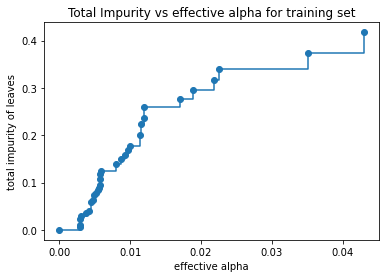

In [22]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
#ax.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

#### Train a decision tree using the effective alphas. The last value in ccp_alphas is the alpha value that prunes the whole tree, leaving the tree, clfs[-1], with one node.

In [23]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.060968520220588185


In [24]:
clfs[0].tree_.node_count

99

#### For the remainder of this example, we remove the last element in clfs and ccp_alphas, because it is the trivial tree with only one node. 

Here we show that the number of nodes and tree depth decreases as alpha increases.

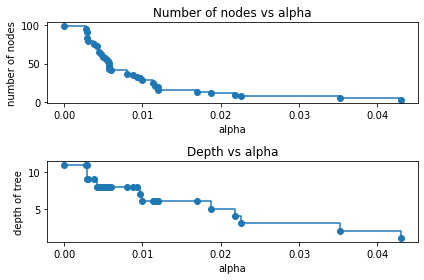

In [25]:
clfs = clfs[:-1] # removing the last element
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

#### Accuracy vs alpha for training and testing sets
When ccp_alpha is set to zero and keeping the other default parameters of DecisionTreeClassifier, the tree overfits, leading to a 100% training accuracy and about 72% testing accuracy. As alpha increases, more of the tree is pruned, thus creating a decision tree that generalizes better. In this example, setting ccp_alpha=0.0057 maximizes the testing accuracy =0.8.

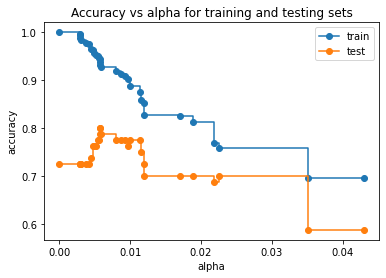

In [26]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

#### Construct the Tree using the best alpha

you can first print the index to see which alpha corresponds to the highest test socore

In [27]:
import operator
index, value = max(enumerate(test_scores), key=operator.itemgetter(1))
print(index)
print(value)
print(len(test_scores))

14
0.8
32


In [28]:
ccp_alphas[14] 

0.005706845238095238

In [29]:
test_scores[14]

0.8

In [30]:
clfs[14].tree_.node_count

47

In [31]:
clfs[14].tree_.max_depth

8

#### Now create the tree using the depth corresponds to the best alph and see the test accuracy of the model 

In [37]:
class_tree_carseats_best_alpha = DecisionTreeClassifier(max_depth=8)
class_tree_carseats_best_alpha.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8)

In [38]:
y_pred = class_tree_carseats_best_alpha.predict(X_test) 
cm = pd.DataFrame(confusion_matrix(y_test, y_pred).T,                   
                  index = ['No', 'Yes'],                   
                  columns = ['No', 'Yes']) 
print(cm) 

     No  Yes
No   35   14
Yes   8   23


In [39]:
#REF: https://towardsdatascience.com/understanding-the-confusion-matrix-and-how-to-implement-it-in-python-319202e0fe4d
# Accuracy
from sklearn.metrics import accuracy_score
accuracy_score=accuracy_score(y_test, y_pred)
print(accuracy_score)
# Recall
from sklearn.metrics import recall_score
recall=recall_score(y_test, y_pred, average='binary')
print(recall)
# Precision
from sklearn.metrics import precision_score
precision=precision_score(y_test, y_pred, average='binary')
print(precision)

0.725
0.6216216216216216
0.7419354838709677


In [40]:
# Method 1: sklearn
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='binary')

0.676470588235294

Logistic: ROC AUC=0.718


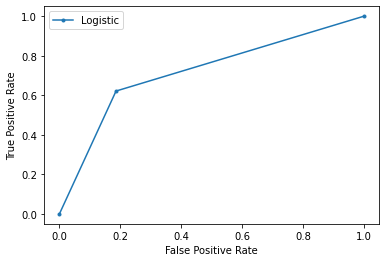

In [41]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
# calculate scores

lr_auc = roc_auc_score(y_test, y_pred)
# summarize scores

print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves


lr_fpr, lr_tpr, thresholds = roc_curve(y_test,  y_pred)
# plot the roc curve for the model

pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [36]:
class_tree_carseats_best_alpha = DecisionTreeClassifier(max_depth=8)
class_tree_carseats_best_alpha.fit(X, y)

DecisionTreeClassifier(max_depth=8)

### ALTERNATIVELY Use the Following Way to Explre Cross Validation

https://towardsdatascience.com/how-to-find-decision-tree-depth-via-cross-validation-2bf143f0f3d6

In [42]:
X = df3.drop(['Sales', 'High'], axis = 1) 
y = df3.High 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 0)

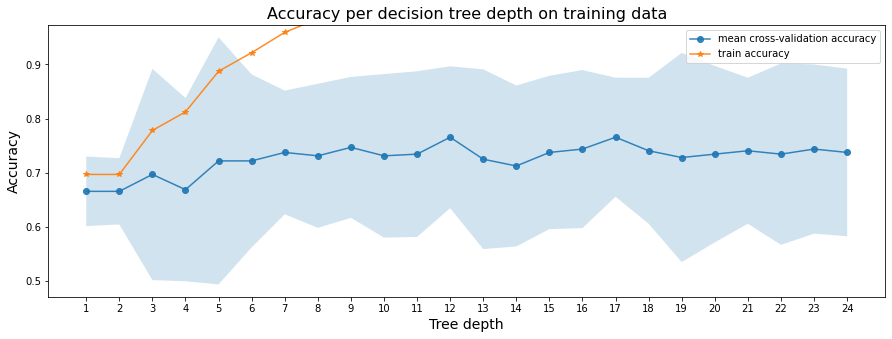

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# function for fitting trees of various depths on the training data using cross-validation
def run_cross_validation_on_trees(X, y, tree_depths, cv=5, scoring='accuracy'):
    cv_scores_list = []
    cv_scores_std = []
    cv_scores_mean = []
    accuracy_scores = []
    for depth in tree_depths:
        tree_model = DecisionTreeClassifier(max_depth=depth)
        cv_scores = cross_val_score(tree_model, X, y, cv=cv, scoring=scoring)
        cv_scores_list.append(cv_scores)
        cv_scores_mean.append(cv_scores.mean())
        cv_scores_std.append(cv_scores.std())
        accuracy_scores.append(tree_model.fit(X, y).score(X, y))
    cv_scores_mean = np.array(cv_scores_mean)
    cv_scores_std = np.array(cv_scores_std)
    accuracy_scores = np.array(accuracy_scores)
    return cv_scores_mean, cv_scores_std, accuracy_scores
  
# function for plotting cross-validation results
def plot_cross_validation_on_trees(depths, cv_scores_mean, cv_scores_std, accuracy_scores, title):
    fig, ax = plt.subplots(1,1, figsize=(15,5))
    ax.plot(depths, cv_scores_mean, '-o', label='mean cross-validation accuracy', alpha=0.9)
    ax.fill_between(depths, cv_scores_mean-2*cv_scores_std, cv_scores_mean+2*cv_scores_std, alpha=0.2)
    ylim = plt.ylim()
    ax.plot(depths, accuracy_scores, '-*', label='train accuracy', alpha=0.9)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Tree depth', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_ylim(ylim)
    ax.set_xticks(depths)
    ax.legend()

# fitting trees of depth 1 to 24
sm_tree_depths = range(1,25)
sm_cv_scores_mean, sm_cv_scores_std, sm_accuracy_scores = run_cross_validation_on_trees(X_train, y_train, sm_tree_depths)

# plotting accuracy
plot_cross_validation_on_trees(sm_tree_depths, sm_cv_scores_mean, sm_cv_scores_std, sm_accuracy_scores, 
                               'Accuracy per decision tree depth on training data')


In [44]:
idx_max = sm_cv_scores_mean.argmax()
sm_best_tree_depth = sm_tree_depths[idx_max]
sm_best_tree_cv_score = sm_cv_scores_mean[idx_max]
sm_best_tree_cv_score_std = sm_cv_scores_std[idx_max]
print('The depth-{} tree achieves the best mean cross-validation accuracy {} +/- {}% on training dataset'.format(
      sm_best_tree_depth, round(sm_best_tree_cv_score*100,5), round(sm_best_tree_cv_score_std*100, 5)))


The depth-12 tree achieves the best mean cross-validation accuracy 76.5625 +/- 6.55506% on training dataset


In [45]:
# function for training and evaluating a tree
def run_single_tree(X_train, y_train, X_test, y_test, depth):
    model = DecisionTreeClassifier(max_depth=depth).fit(X_train, y_train)
    accuracy_train = model.score(X_train, y_train)
    accuracy_test = model.score(X_test, y_test)
    print('Single tree depth: ', depth)
    print('Accuracy, Training Set: ', round(accuracy_train*100,5), '%')
    print('Accuracy, Test Set: ', round(accuracy_test*100,5), '%')
    return accuracy_train, accuracy_test
  

# train and evaluate a 5-depth tree
sm_best_tree_accuracy_train, sm_best_tree_accuracy_test = run_single_tree(X_train, y_train, 
                                                                          X_test, y_test, 
                                                                          sm_best_tree_depth)

Single tree depth:  12
Accuracy, Training Set:  100.0 %
Accuracy, Test Set:  72.5 %
